In [6]:
pip install psycopg2-binary sqlalchemy vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.5 MB/s eta 0:00:00


In [7]:
import pandas as pd

df = pd.read_csv('customer_reviews_cleaned.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1400, 6)
   reviewid  customerid  productid  reviewdate  rating  \
0         1         204         21  2024-09-17       5   
1         2         226         23  2023-08-31       5   
2         3         192         15  2023-01-08       4   
3         4         298         13  2024-02-17       5   
4         5         156         48  2024-01-24       3   

                                          reviewtext  
0       Excellent product. Myntra never disappoints.  
1  Delivery was quick and product is exactly as d...  
2          Amazing quality! Totally worth the price.  
3      Fits perfectly. Very happy with the purchase.  
4  Material is fine but the colour is slightly di...  
['reviewid', 'customerid', 'productid', 'reviewdate', 'rating', 'reviewtext']


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# get VADER compound score for each review
df['vader_score'] = df['reviewtext'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(df[['reviewtext', 'rating', 'vader_score']].head(10))

                                          reviewtext  rating  vader_score
0       Excellent product. Myntra never disappoints.       5       0.7081
1  Delivery was quick and product is exactly as d...       5       0.0000
2          Amazing quality! Totally worth the price.       4       0.7419
3      Fits perfectly. Very happy with the purchase.       5       0.8479
4  Material is fine but the colour is slightly di...       3       0.1027
5       Excellent product. Myntra never disappoints.       5       0.7081
6     Product looks different from the photo online.       1       0.0000
7       Excellent product. Myntra never disappoints.       5       0.7081
8   Beautiful design. Exactly as shown in the photo.       5       0.5994
9      Fits perfectly. Very happy with the purchase.       5       0.8479


In [9]:
# hybrid sentiment: combines VADER score + star rating
# because VADER alone misses sarcasm and context
# example: "The quality is top-notch" scores 0.0 on VADER but is clearly positive
# adding star rating fixes these gaps

def hybrid_sentiment(row):
    vader = row['vader_score']
    rating = row['rating']

    if rating >= 4 and vader >= 0.05:
        return 'Positive'
    elif rating >= 4 and vader < 0.05:
        return 'Mixed Positive'
    elif rating == 3:
        return 'Neutral'
    elif rating <= 2 and vader <= -0.05:
        return 'Negative'
    else:
        return 'Mixed Negative'

df['sentiment_category'] = df.apply(hybrid_sentiment, axis=1)

print(df['sentiment_category'].value_counts())

sentiment_category
Positive          962
Neutral           135
Negative          118
Mixed Positive    107
Mixed Negative     78
Name: count, dtype: int64


In [10]:
import pandas as pd

df = pd.read_csv('customer_reviews_cleaned.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1400, 6)
   reviewid  customerid  productid  reviewdate  rating  \
0         1         204         21  2024-09-17       5   
1         2         226         23  2023-08-31       5   
2         3         192         15  2023-01-08       4   
3         4         298         13  2024-02-17       5   
4         5         156         48  2024-01-24       3   

                                          reviewtext  
0       Excellent product. Myntra never disappoints.  
1  Delivery was quick and product is exactly as d...  
2          Amazing quality! Totally worth the price.  
3      Fits perfectly. Very happy with the purchase.  
4  Material is fine but the colour is slightly di...  
['reviewid', 'customerid', 'productid', 'reviewdate', 'rating', 'reviewtext']


In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# get VADER compound score for each review
df['vader_score'] = df['reviewtext'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(df[['reviewtext', 'rating', 'vader_score']].head(10))

                                          reviewtext  rating  vader_score
0       Excellent product. Myntra never disappoints.       5       0.7081
1  Delivery was quick and product is exactly as d...       5       0.0000
2          Amazing quality! Totally worth the price.       4       0.7419
3      Fits perfectly. Very happy with the purchase.       5       0.8479
4  Material is fine but the colour is slightly di...       3       0.1027
5       Excellent product. Myntra never disappoints.       5       0.7081
6     Product looks different from the photo online.       1       0.0000
7       Excellent product. Myntra never disappoints.       5       0.7081
8   Beautiful design. Exactly as shown in the photo.       5       0.5994
9      Fits perfectly. Very happy with the purchase.       5       0.8479


In [19]:
# hybrid sentiment: combines VADER score + star rating
# because VADER alone misses sarcasm and context
# example: "The quality is top-notch" scores 0.0 on VADER but is clearly positive
# adding star rating fixes these gaps

def hybrid_sentiment(row):
    vader = row['vader_score']
    rating = row['rating']

    if rating >= 4 and vader >= 0.05:
        return 'Positive'
    elif rating >= 4 and vader < 0.05:
        return 'Mixed Positive'
    elif rating == 3:
        return 'Neutral'
    elif rating <= 2 and vader <= -0.05:
        return 'Negative'
    else:
        return 'Mixed Negative'

df['sentiment_category'] = df.apply(hybrid_sentiment, axis=1)

print(df['sentiment_category'].value_counts())

sentiment_category
Positive          962
Neutral           135
Negative          118
Mixed Positive    107
Mixed Negative     78
Name: count, dtype: int64


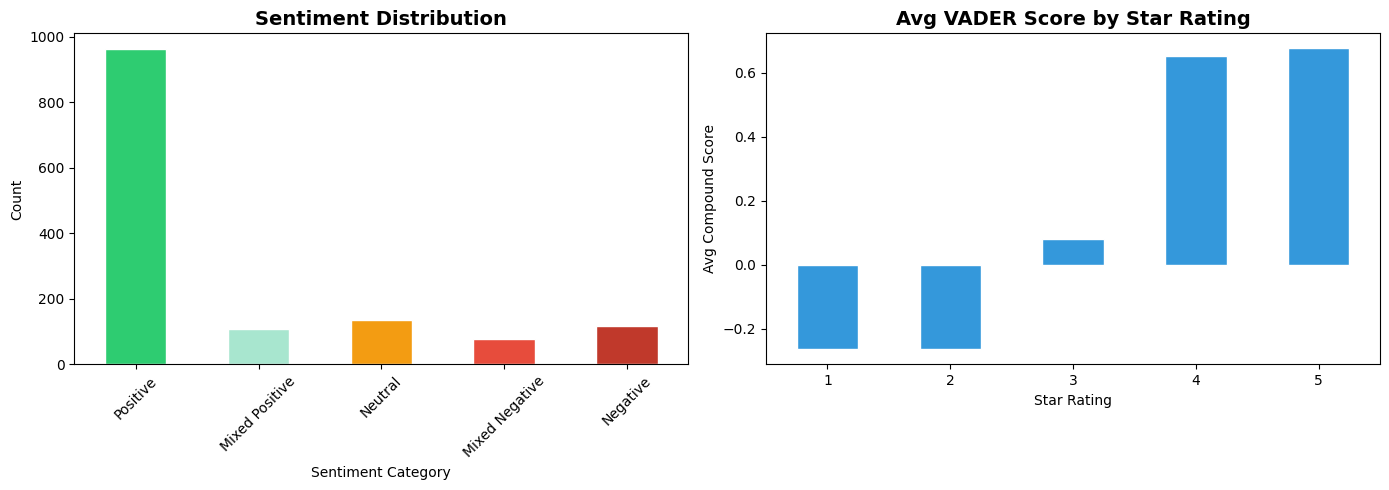

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: sentiment category counts
sentiment_order = ['Positive', 'Mixed Positive', 'Neutral', 'Mixed Negative', 'Negative']
colors = ['#2ecc71', '#a8e6cf', '#f39c12', '#e74c3c', '#c0392b']

df['sentiment_category'].value_counts().reindex(sentiment_order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# plot 2: avg vader score by star rating
df.groupby('rating')['vader_score'].mean().plot(
    kind='bar', ax=axes[1], color='#3498db', edgecolor='white'
)
axes[1].set_title('Avg VADER Score by Star Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Compound Score')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [21]:
from collections import Counter
import re

# filter only negative reviews
negative_reviews = df[df['sentiment_category'] == 'Negative']['reviewtext']

# clean and extract words
def extract_words(text):
    text = str(text).lower()
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    # remove common stopwords
    stopwords = ['the', 'is', 'it', 'and', 'a', 'an', 'i', 'was', 'my',
                 'very', 'but', 'not', 'for', 'to', 'of', 'in', 'this',
                 'product', 'are', 'be', 'at', 'me', 'so', 'its', 'with']
    return [w for w in words if w not in stopwords and len(w) > 2]

all_words = []
for review in negative_reviews:
    all_words.extend(extract_words(review))

# top 15 words in negative reviews
word_freq = Counter(all_words).most_common(15)
print("Top 15 words in negative reviews:")
for word, count in word_freq:
    print(f"  {word}: {count}")

Top 15 words in negative reviews:
  size: 24
  runs: 24
  small: 24
  return: 24
  process: 24
  difficult: 24
  color: 22
  faded: 22
  after: 22
  first: 22
  wash: 22
  disappointing: 22
  received: 20
  damaged: 20
  unhappy: 20


In [22]:
import pandas as pd

# load products CSV
products = pd.read_csv('products.csv')

# lowercase all column names for consistency
products.columns = products.columns.str.lower()

print(products.columns.tolist())
print(products.head())

['productid', 'productname', 'brand', 'category', 'price', 'mrp', 'discountpercent', 'avgrating', 'numberofratings']
   productid                 productname           brand           category  \
0          1  Men Loose Fit Cotton Jeans           WROGN  Relaxed Fit Jeans   
1          2          Men Slim Fit Jeans  Flying Machine     Slim Fit Jeans   
2          3       Men Pure Cotton Jeans        Roadster      Denim & Jeans   
3          4     Relaxed Fit Denim Jeans      Bene Kleed  Relaxed Fit Jeans   
4          5      Men 511 Slim Fit Jeans           Levis     Slim Fit Jeans   

    price     mrp  discountpercent  avgrating  numberofratings  
0  1374.0  2499.0              0.4        4.2               57  
1  1829.0  2999.0              0.4        4.6                5  
2   974.0  2499.0              0.6        3.6             1100  
3   873.0  2299.0              0.6        4.0             4800  
4  1478.0  2899.0              0.5        4.3              264  


In [23]:
# merge reviews dataframe with products on productid
df_merged = df.merge(products, on='productid', how='left')

print(df_merged.shape)
print(df_merged[['reviewid', 'rating', 'sentiment_category', 'productname', 'category']].head())

(1400, 16)
   reviewid  rating sentiment_category                     productname  \
0         1       5           Positive       Men Low-Rise Cargo  Jeans   
1         2       5     Mixed Positive           Men Stretchable Jeans   
2         3       4           Positive     Men Mid-Rise Boot Cut Jeans   
3         4       5           Positive  Men Slim Fit Stretchable Jeans   
4         5       3            Neutral               Men Bootcut Jeans   

             category  
0     Joggers & Cargo  
1   Stretchable Jeans  
2       Denim & Jeans  
3      Slim Fit Jeans  
4  Wide Leg & Bootcut  


In [24]:
# sentiment distribution by product category
category_sentiment = df_merged.groupby(['category', 'sentiment_category']).size().unstack(fill_value=0)

print(category_sentiment)
print()

# negative review rate by category
category_sentiment['total'] = category_sentiment.sum(axis=1)
category_sentiment['negative_rate_pct'] = round(
    category_sentiment.get('Negative', 0) * 100 / category_sentiment['total'], 1
)

print(category_sentiment[['total', 'negative_rate_pct']].sort_values('negative_rate_pct', ascending=False))

sentiment_category  Mixed Negative  Mixed Positive  Negative  Neutral  \
category                                                                
Denim & Jeans                   13              15         8       12   
Joggers & Cargo                  2               7         9        6   
Regular Fit Jeans                8              16        16       19   
Relaxed Fit Jeans               21              18        37       24   
Slim Fit Jeans                  17              23        28       33   
Stretchable Jeans                7              14        13       14   
Wide Leg & Bootcut              10              14         7       27   

sentiment_category  Positive  
category                      
Denim & Jeans            132  
Joggers & Cargo           35  
Regular Fit Jeans        145  
Relaxed Fit Jeans        197  
Slim Fit Jeans           225  
Stretchable Jeans         87  
Wide Leg & Bootcut       141  

sentiment_category  total  negative_rate_pct
category         

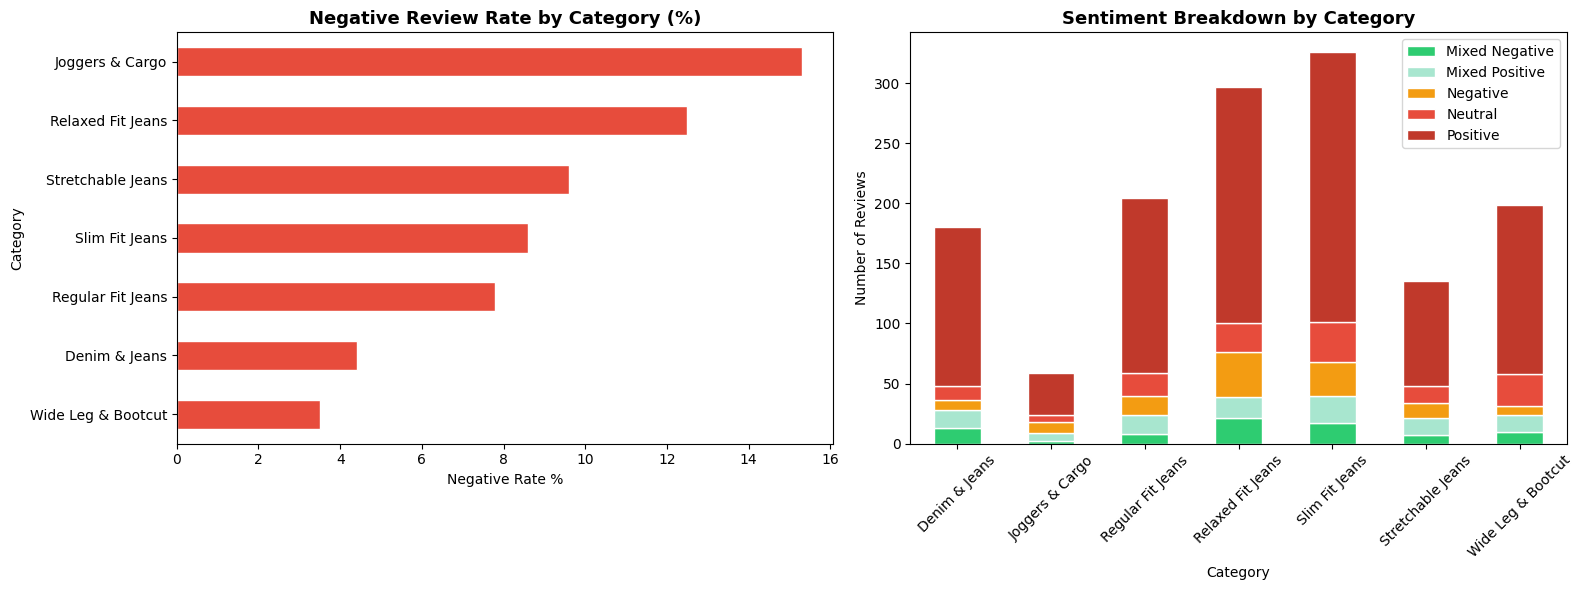

In [25]:
import matplotlib.pyplot as plt

# plot negative rate by category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 1: negative rate % by category
category_sentiment['negative_rate_pct'].sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[0],
    color='#e74c3c',
    edgecolor='white'
)
axes[0].set_title('Negative Review Rate by Category (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Negative Rate %')
axes[0].set_ylabel('Category')

# plot 2: full sentiment breakdown by category (stacked bar)
sentiment_cols = [col for col in category_sentiment.columns
                  if col in ['Positive', 'Mixed Positive', 'Neutral', 'Mixed Negative', 'Negative']]
colors = ['#2ecc71', '#a8e6cf', '#f39c12', '#e74c3c', '#c0392b']

category_sentiment[sentiment_cols].plot(
    kind='bar',
    ax=axes[1],
    color=colors[:len(sentiment_cols)],
    edgecolor='white',
    stacked=True
)
axes[1].set_title('Sentiment Breakdown by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [26]:
# sentiment trend over time (month by month)
df_merged['reviewdate'] = pd.to_datetime(df_merged['reviewdate'])
df_merged['year_month'] = df_merged['reviewdate'].dt.to_period('M')

# count sentiment categories per month
monthly_sentiment = df_merged.groupby(['year_month', 'sentiment_category']).size().unstack(fill_value=0)

# calculate monthly negative rate
monthly_sentiment['total'] = monthly_sentiment.sum(axis=1)
monthly_sentiment['negative_rate_pct'] = round(
    monthly_sentiment.get('Negative', 0) * 100 / monthly_sentiment['total'], 1
)

print(monthly_sentiment[['total', 'negative_rate_pct']].head(10))

sentiment_category  total  negative_rate_pct
year_month                                  
2023-01                61                1.6
2023-02                61                6.6
2023-03                49               12.2
2023-04                45                4.4
2023-05                59                8.5
2023-06                55               12.7
2023-07                51               17.6
2023-08                53                7.5
2023-09                55                9.1
2023-10                73                5.5


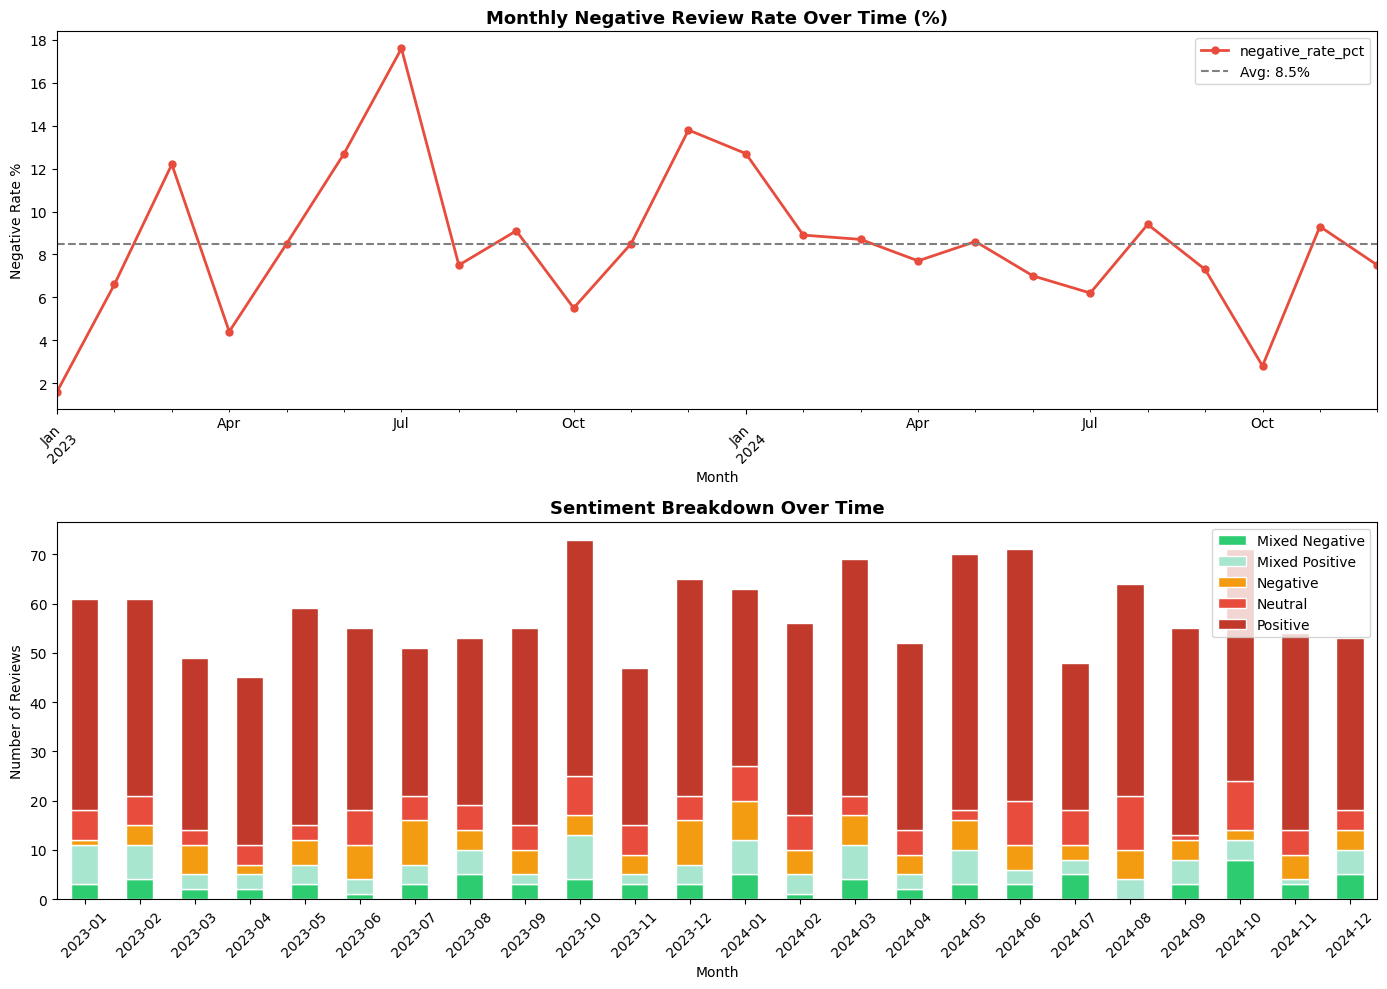

In [27]:
# plot sentiment trend over time
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# plot 1: monthly negative rate trend line
monthly_sentiment['negative_rate_pct'].plot(
    ax=axes[0],
    color='#e74c3c',
    linewidth=2,
    marker='o',
    markersize=5
)
axes[0].set_title('Monthly Negative Review Rate Over Time (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Negative Rate %')
axes[0].axhline(
    y=monthly_sentiment['negative_rate_pct'].mean(),
    color='gray',
    linestyle='--',
    label=f"Avg: {monthly_sentiment['negative_rate_pct'].mean():.1f}%"
)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# plot 2: full sentiment breakdown over time (stacked bar)
sentiment_cols = [col for col in monthly_sentiment.columns
                  if col in ['Positive', 'Mixed Positive', 'Neutral', 'Mixed Negative', 'Negative']]
colors = ['#2ecc71', '#a8e6cf', '#f39c12', '#e74c3c', '#c0392b']

monthly_sentiment[sentiment_cols].plot(
    kind='bar',
    ax=axes[1],
    color=colors[:len(sentiment_cols)],
    edgecolor='white',
    stacked=True
)
axes[1].set_title('Sentiment Breakdown Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [28]:
# find reviews where star rating and VADER disagree
# these are interesting edge cases — possible fake reviews or sarcasm

mismatch = df_merged[
    ((df_merged['rating'] >= 4) & (df_merged['vader_score'] < -0.05)) |  # high rating, negative VADER
    ((df_merged['rating'] <= 2) & (df_merged['vader_score'] > 0.05))      # low rating, positive VADER
].copy()

mismatch['mismatch_type'] = mismatch.apply(
    lambda row: 'Suspicious Positive (High Rating, Negative Text)'
    if row['rating'] >= 4 else 'Suspicious Negative (Low Rating, Positive Text)',
    axis=1
)

print(f"Total mismatch reviews: {len(mismatch)}")
print()
print(mismatch[['reviewid', 'rating', 'vader_score', 'mismatch_type', 'reviewtext']].head(10))

Total mismatch reviews: 12

      reviewid  rating  vader_score  \
176        177       2       0.4019   
386        387       1       0.4019   
396        397       1       0.4019   
569        570       1       0.4019   
824        825       1       0.4019   
841        842       2       0.4019   
1057      1058       2       0.4019   
1286      1287       2       0.4019   
1295      1296       2       0.4019   
1303      1304       1       0.4019   

                                        mismatch_type  \
176   Suspicious Negative (Low Rating, Positive Text)   
386   Suspicious Negative (Low Rating, Positive Text)   
396   Suspicious Negative (Low Rating, Positive Text)   
569   Suspicious Negative (Low Rating, Positive Text)   
824   Suspicious Negative (Low Rating, Positive Text)   
841   Suspicious Negative (Low Rating, Positive Text)   
1057  Suspicious Negative (Low Rating, Positive Text)   
1286  Suspicious Negative (Low Rating, Positive Text)   
1295  Suspicious Negative (Lo

In [30]:
# export final enriched dataframe for Power BI
final_df = df_merged[[
    'reviewid', 'customerid', 'productid', 'reviewdate', 'year_month',
    'rating', 'reviewtext', 'vader_score', 'sentiment_category',
    'productname', 'brand', 'category', 'price'
]].copy()

# convert year_month back to string for export
final_df['year_month'] = final_df['year_month'].astype(str)

# save to CSV
final_df.to_csv('myntra_sentiment_output.csv', index=False)

print(f"Exported {len(final_df)} rows")
print(f"Columns: {final_df.columns.tolist()}")
print()
print(final_df.head())

Exported 1400 rows
Columns: ['reviewid', 'customerid', 'productid', 'reviewdate', 'year_month', 'rating', 'reviewtext', 'vader_score', 'sentiment_category', 'productname', 'brand', 'category', 'price']

   reviewid  customerid  productid reviewdate year_month  rating  \
0         1         204         21 2024-09-17    2024-09       5   
1         2         226         23 2023-08-31    2023-08       5   
2         3         192         15 2023-01-08    2023-01       4   
3         4         298         13 2024-02-17    2024-02       5   
4         5         156         48 2024-01-24    2024-01       3   

                                          reviewtext  vader_score  \
0       Excellent product. Myntra never disappoints.       0.7081   
1  Delivery was quick and product is exactly as d...       0.0000   
2          Amazing quality! Totally worth the price.       0.7419   
3      Fits perfectly. Very happy with the purchase.       0.8479   
4  Material is fine but the colour is sligh

In [29]:
# sentiment bucketing — groups vader score into 4 ranges
def sentiment_bucket(score):
    if score >= 0.5:
        return '0.5 to 1.0'
    elif 0.0 <= score < 0.5:
        return '0.0 to 0.49'
    elif -0.5 <= score < 0.0:
        return '-0.49 to 0.0'
    else:
        return '-1.0 to -0.5'

df_merged['sentiment_bucket'] = df_merged['vader_score'].apply(sentiment_bucket)

# issue categorization on negative reviews
def categorize_issue(text):
    text = str(text).lower()
    if any(word in text for word in ['worth', 'money', 'expensive', 'price', 'costly']):
        return 'Product Cost'
    elif any(word in text for word in ['arrived', 'late', 'delivery', 'shipping']):
        return 'Delivery'
    elif any(word in text for word in ['meet', 'expectations', 'average', 'nothing', 'special']):
        return 'Unmet Expectations'
    elif any(word in text for word in ['stopped', 'working', 'broke', 'month']):
        return 'Durability'
    elif any(word in text for word in ['performance', 'disappointed', 'bad', 'terrible']):
        return 'Product Performance'
    elif any(word in text for word in ['instructions', 'unclear', 'confusing']):
        return 'Usability'
    elif any(word in text for word in ['customer', 'service', 'support']):
        return 'Customer Service'
    else:
        return 'General Dissatisfaction'

df_negative = df_merged[df_merged['sentiment_category'] == 'Negative'].copy()
df_negative['issue_category'] = df_negative['reviewtext'].apply(categorize_issue)

print(df_negative['issue_category'].value_counts())

# export negative reviews separately
df_negative.to_csv('myntra_negative_issues.csv', index=False)
print("negative reviews exported!")

issue_category
General Dissatisfaction    66
Product Cost               18
Product Performance        18
Delivery                   16
Name: count, dtype: int64
negative reviews exported!
